In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset

df = pd.read_csv("../dataset/manet_dataset.csv")

print("Dataset loaded")
print("Shape:", df.shape)

df.head()

Dataset loaded
Shape: (54000, 12)


,run_id,time,node_id,x,y,neighbor_count,avg_rssi,tx_packets,rx_packets,lost_packets,delay_sum,link_failure
0,9,1.0,0.0,72.955,1.839,1.0,-3.993,0,0,0,0.0,1
1,9,1.0,1.0,477.050,418.620,3.0,-37.570,0,0,0,0.0,0
2,9,1.0,2.0,22.462,160.934,2.0,-41.436,0,0,0,0.0,1
3,9,1.0,3.0,477.311,378.324,2.0,-35.513,0,0,0,0.0,0
4,9,1.0,4.0,272.095,354.846,0.0,-1000.000,0,0,0,0.0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   run_id          54000 non-null  int64  
 1   time            54000 non-null  float64
 2   node_id         54000 non-null  float64
 3   x               54000 non-null  float64
 4   y               54000 non-null  float64
 5   neighbor_count  54000 non-null  float64
 6   avg_rssi        54000 non-null  float64
 7   tx_packets      54000 non-null  int64  
 8   rx_packets      54000 non-null  int64  
 9   lost_packets    54000 non-null  int64  
 10  delay_sum       54000 non-null  float64
 11  link_failure    54000 non-null  int64  
dtypes: float64(7), int64(5)
memory usage: 4.9 MB


In [4]:
df.describe()

,run_id,time,node_id,x,y,neighbor_count,avg_rssi,tx_packets,rx_packets,lost_packets,delay_sum,link_failure
count,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.0,54000.0,54000.0,54000.0,54000.000000
mean,15.500000,30.500000,14.500000,257.575923,247.070111,5.238889,-77.792592,0.0,0.0,0.0,0.0,0.207130
std,8.655522,17.318263,8.655522,121.368517,109.706967,3.488528,194.992353,0.0,0.0,0.0,0.0,0.405253
min,1.000000,1.000000,0.000000,0.674000,1.839000,0.000000,-1000.000000,0.0,0.0,0.0,0.0,0.000000
25%,8.000000,15.750000,7.000000,163.303250,173.232250,2.000000,-39.344000,0.0,0.0,0.0,0.0,0.000000
50%,15.500000,30.500000,14.500000,261.090000,253.155500,5.000000,-37.387000,0.0,0.0,0.0,0.0,0.000000
75%,23.000000,45.250000,22.000000,352.591500,323.714000,8.000000,-34.915000,0.0,0.0,0.0,0.0,0.000000
max,30.000000,60.000000,29.000000,495.990000,493.956000,15.000000,-3.993000,0.0,0.0,0.0,0.0,1.000000


In [5]:
# Check class balance

df["link_failure"].value_counts()

link_failure
0    42815
1    11185
Name: count, dtype: int64

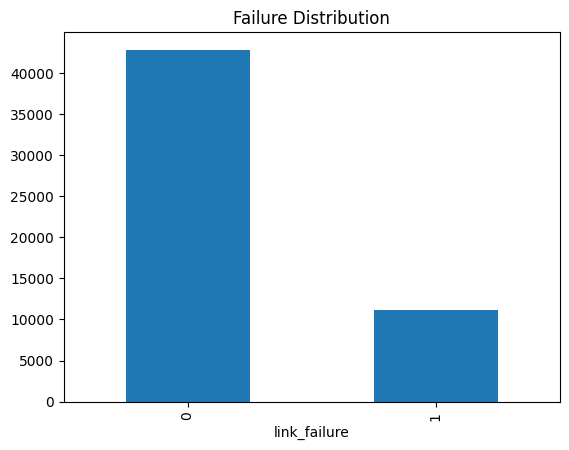

In [6]:
df["link_failure"].value_counts().plot(kind="bar")
plt.title("Failure Distribution")
plt.show()

In [7]:
# Select ML features

# features = ["neighbor_count", "avg_rssi", "x", "y", "time"]
features = ["neighbor_count", "x", "y", "time"]

X = df[features]
y = df["link_failure"]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (54000, 4)


In [18]:
# Train / Validation / Test split

from sklearn.model_selection import train_test_split

# 70% train, 30% remaining
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# split remaining into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_remaining, y_remaining,
    test_size=0.50,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 37800
Validation: 8100
Test: 8100


In [19]:
# Feature scaling (Needed for neural networks later)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [20]:
# Train Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest trained")

Random Forest trained


In [21]:
# Evaluate Random Forest

rf_preds = rf.predict(X_test)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      6413
           1       0.90      0.60      0.72      1687

    accuracy                           0.90      8100
   macro avg       0.90      0.79      0.83      8100
weighted avg       0.90      0.90      0.89      8100



In [22]:
# Confusion matrix

cm = confusion_matrix(y_test, rf_preds)

print(cm)

[[6300  113]
 [ 679 1008]]


ROC AUC: 0.7882762775042655


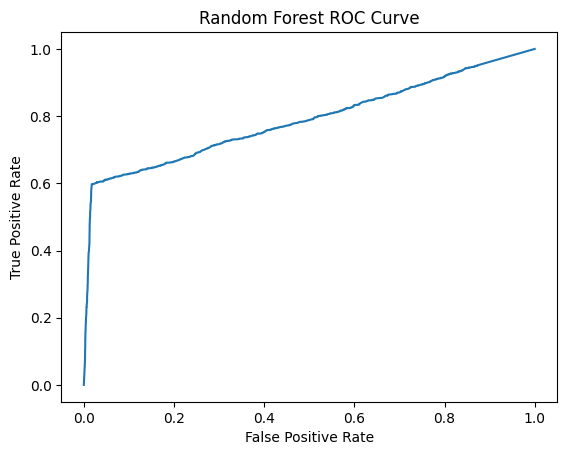

In [23]:
# ROC curve

rf_probs = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, rf_probs)
print("ROC AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr, tpr)
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [24]:
# Feature importance

importance = rf.feature_importances_

for f, i in zip(features, importance):
    print(f, ":", round(i,3))

neighbor_count : 0.82
x : 0.063
y : 0.081
time : 0.035


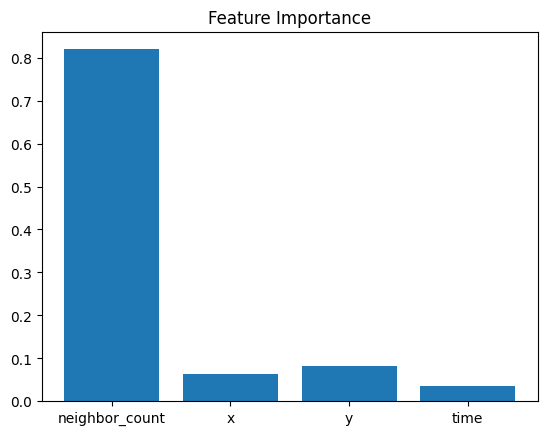

In [25]:
plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()